In [11]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Sequential ,load_model
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [12]:
img_size = (480, 480)
batch_size = 64

img_gen = ImageDataGenerator(rescale= 1./255.,
        shear_range=0.2,
        zoom_range=0.2,
        width_shift_range=0.2,
        height_shift_range=0.2)

In [13]:
train_gen = img_gen.flow_from_directory( "V3/Training/",
                                        target_size = img_size ,
                                        class_mode = 'categorical' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =batch_size)

valid_gen = img_gen.flow_from_directory( "V3/Testing/",
                                        target_size = img_size ,
                                        class_mode = 'categorical' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =batch_size)
test_gen = img_gen.flow_from_directory( "V3/Testing/",
                                        target_size = img_size ,
                                        class_mode = 'categorical' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =batch_size)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [14]:
target =list(train_gen.class_indices)
target

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

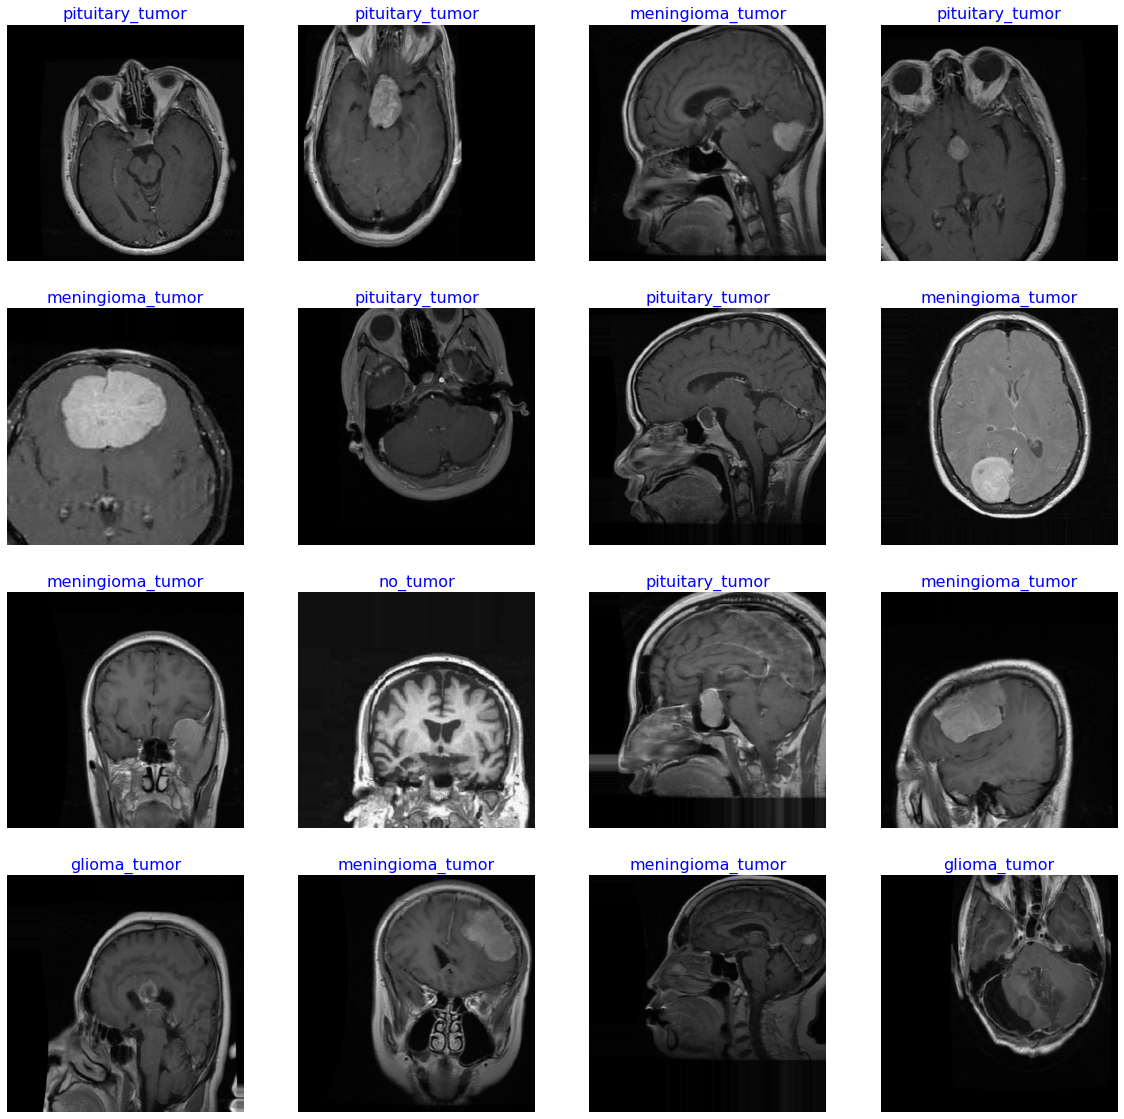

In [15]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_gen)

plt.figure(figsize= (20,20))

for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i]
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name , color = 'blue' , fontsize= 16)
    plt.axis('off')
plt.show();

In [16]:
img_shape = (img_size[0] , img_size[1] , 3)

base_model = InceptionV3(input_shape = img_shape, weights='imagenet', include_top=False)

In [17]:
base_model.trainable = False
# for layer in base_model.layers[:-2]:
#     layer.trainable = False

model = Sequential([
    base_model,
    
    # there is an error and fixed with padding and remove input shape from conv
    Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    Flatten(input_shape=img_shape),
    
    Dense(64,activation='relu'),
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dropout(rate = 0.3),
    
    Dense(256,activation='relu'),
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dropout(rate = 0.3),

    Dense(128,activation='relu'),
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dropout(rate = 0.3),
    Dense(4, activation='softmax')
])

In [18]:
model.compile(Adam(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 13, 13, 2048)      21802784  
                                                                 
 conv2d_94 (Conv2D)          (None, 13, 13, 256)       4718848   
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 6, 6, 256)         0         
 g2D)                                                            
                                                                 
 conv2d_95 (Conv2D)          (None, 6, 6, 128)         295040    
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 3, 3, 128)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1152)              0

In [19]:
checkpoint = keras.callbacks.ModelCheckpoint('BrainTumor_model_2_480px_v6.h5',
                                                monitor='accuracy', verbose=1,
                                                mode='max',save_best_only=True)
early = keras.callbacks.EarlyStopping(monitor="accuracy",
                                         mode="max",
                                         restore_best_weights=True,
                                         patience=5)
callbacks_list = [checkpoint,early]

history = model.fit(x=train_gen ,
                    epochs = 100 ,
                    verbose = 1 ,
                    validation_data = valid_gen ,
                    validation_steps = None,
                    shuffle = False,
                    callbacks=callbacks_list)

Epoch 1/100
45/45 [==============================] - ETA: 0s - loss: 1.6320 - accuracy: 0.3721 
Epoch 1: accuracy improved from -inf to 0.37213, saving model to BrainTumor_model_2_480px_v6.h5


C:\Users\AI\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 883s 19s/step - loss: 1.6320 - accuracy: 0.3721 - val_loss: 5.2750 - val_accuracy: 0.1878
Epoch 2/100
45/45 [==============================] - ETA: 0s - loss: 1.1743 - accuracy: 0.5328 
Epoch 2: accuracy improved from 0.37213 to 0.53275, saving model to BrainTumor_model_2_480px_v6.h5
45/45 [==============================] - 874s 19s/step - loss: 1.1743 - accuracy: 0.5328 - val_loss: 1.5339 - val_accuracy: 0.3706
Epoch 3/100
45/45 [==============================] - ETA: 0s - loss: 0.8239 - accuracy: 0.6854 
Epoch 3: accuracy improved from 0.53275 to 0.68537, saving model to BrainTumor_model_2_480px_v6.h5
45/45 [==============================] - 873s 19s/step - loss: 0.8239 - accuracy: 0.6854 - val_loss: 1.6638 - val_accuracy: 0.4721
Epoch 4/100
45/45 [==============================] - ETA: 0s - loss: 0.6453 - accuracy: 0.7488 
Epoch 4: accuracy improved from 0.68537 to 0.74878, saving model to BrainTumor_model_2_480px_v6.h5
45/45 [===============

Epoch 28/100
45/45 [==============================] - ETA: 0s - loss: 0.1056 - accuracy: 0.9672 
Epoch 28: accuracy improved from 0.96272 to 0.96725, saving model to BrainTumor_model_2_480px_v6.h5
45/45 [==============================] - 887s 20s/step - loss: 0.1056 - accuracy: 0.9672 - val_loss: 2.0978 - val_accuracy: 0.6675
Epoch 29/100
45/45 [==============================] - ETA: 0s - loss: 0.1059 - accuracy: 0.9613 
Epoch 29: accuracy did not improve from 0.96725
45/45 [==============================] - 882s 20s/step - loss: 0.1059 - accuracy: 0.9613 - val_loss: 1.6145 - val_accuracy: 0.6929
Epoch 30/100
45/45 [==============================] - ETA: 0s - loss: 0.1062 - accuracy: 0.9610 
Epoch 30: accuracy did not improve from 0.96725
45/45 [==============================] - 878s 19s/step - loss: 0.1062 - accuracy: 0.9610 - val_loss: 1.4199 - val_accuracy: 0.7665
Epoch 31/100
45/45 [==============================] - ETA: 0s - loss: 0.0811 - accuracy: 0.9732 
Epoch 31: accuracy impr

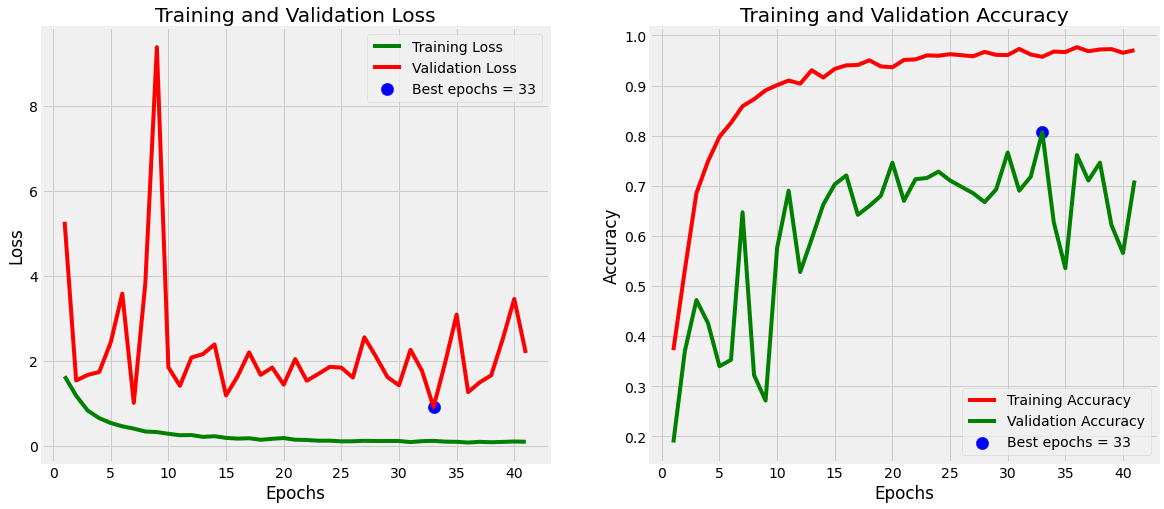

In [20]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'g' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'r' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [21]:
model = load_model("BrainTumor_model_2_480px_v6.h5")

In [22]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 [==============================] - 100s 5s/step - loss: 1.2941 - accuracy: 0.7563
Train Loss:  0.07898179441690445
Train Accuracy:  0.9755859375
--------------------
Validation Loss:  1.3113288879394531
Validation Accuracy:  0.7563451528549194
--------------------
Test Loss:  1.2940847873687744
Test Accuracy:  0.7563451528549194


In [23]:
preds = model.predict_generator(test_gen)
 
y_pred = np.argmax(preds , axis = 1)

C:\Users\AI\AppData\Local\Temp\ipykernel_4148\2676014075.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model.predict_generator(test_gen)


C:\Users\AI\AppData\Local\Temp\ipykernel_4148\4042956973.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


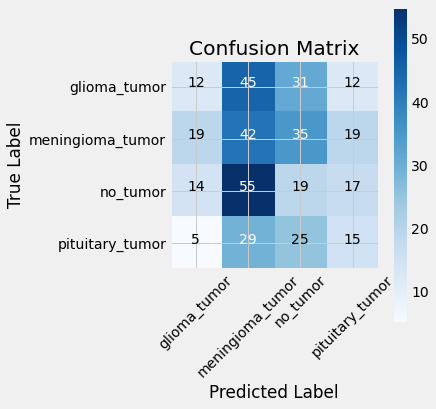

In [24]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (6, 6))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [25]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

                  precision    recall  f1-score   support

    glioma_tumor       0.24      0.12      0.16       100
meningioma_tumor       0.25      0.37      0.29       115
        no_tumor       0.17      0.18      0.18       105
 pituitary_tumor       0.24      0.20      0.22        74

        accuracy                           0.22       394
       macro avg       0.22      0.22      0.21       394
    weighted avg       0.22      0.22      0.21       394

